<a href="https://colab.research.google.com/github/emmanuelvillada573/laboratorio1/blob/laboratorio_2/taller_exploratorio_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
from google.colab import drive



In [2]:


drive.mount('/content/drive')

Mounted at /content/drive


In [3]:

file_path = '/content/drive/MyDrive/Colab Notebooks/DA_Talento/data/dataset_banco.csv'
data  = pd.read_csv(file_path)

display(data.info())

display(data.head())

display(data.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45215 entries, 0 to 45214
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   age        45215 non-null  int64  
 1   job        45213 non-null  object 
 2   marital    45214 non-null  object 
 3   education  45214 non-null  object 
 4   default    45215 non-null  object 
 5   balance    45213 non-null  float64
 6   housing    45215 non-null  object 
 7   loan       45215 non-null  object 
 8   contact    45215 non-null  object 
 9   day        45215 non-null  int64  
 10  month      45215 non-null  object 
 11  duration   45214 non-null  float64
 12  campaign   45215 non-null  int64  
 13  pdays      45214 non-null  float64
 14  previous   45215 non-null  int64  
 15  poutcome   45215 non-null  object 
 16  y          45215 non-null  object 
dtypes: float64(3), int64(4), object(10)
memory usage: 5.9+ MB


None

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143.0,yes,no,unknown,5,may,261.0,1,-1.0,0,unknown,no
1,44,technician,single,secondary,no,29.0,yes,no,unknown,5,may,151.0,1,-1.0,0,unknown,no
2,33,entrepreneur,married,secondary,no,2.0,yes,yes,unknown,5,may,76.0,1,-1.0,0,unknown,no
3,47,blue-collar,married,unknown,no,1506.0,yes,no,unknown,5,may,92.0,1,-1.0,0,unknown,no
4,33,unknown,single,unknown,no,1.0,no,no,unknown,5,may,198.0,1,-1.0,0,unknown,no


,age,balance,day,duration,campaign,pdays,previous
count,45215.000000,45213.000000,45215.000000,45214.000000,45215.000000,45214.000000,45215.000000
mean,41.004711,1374.159866,15.805839,258.074357,2.763729,40.192485,0.580383
std,12.036647,3924.255525,8.322473,257.605175,3.097910,100.120622,2.303438
min,18.000000,-8019.000000,1.000000,-1389.000000,1.000000,-1.000000,0.000000
25%,33.000000,72.000000,8.000000,103.000000,1.000000,-1.000000,0.000000
50%,39.000000,448.000000,16.000000,180.000000,2.000000,-1.000000,0.000000
75%,48.000000,1428.000000,21.000000,319.000000,3.000000,-1.000000,0.000000
max,776.000000,527532.000000,31.000000,4918.000000,63.000000,871.000000,275.000000


Preguntas:

Preguntas - Nivel descriptivo
1. ¿Cuántas observaciones y variables tiene el dataset?  45215 datos y 17 columnas o variables
2. ¿Qué tipos de variables existen (numéricas / categóricas)?  númericas: 7 y categoricas : 10
3. ¿Cuál crees que es la variable más importante y por qué? creeria que es y, ya que indica si esa persona acepta o no el producto
4. ¿Qué variables parecen tener escalas muy diferentes? El balance y la duracion
5. ¿Qué variables podrían requerir transformación? contact, poutcome, education


Preguntas – Nivel crítico

6. ¿Qué información no puedes obtener solo con describe()? no puedo obtener informacion de las columnas categoricas

7. ¿Por qué describe() no muestra variables categóricas? porque no se pueden hacer los calculos matematicos con estos objetos

8. ¿Qué variable podría generar problemas si se analiza solo con promedios? previous

In [4]:
display(data['y'].value_counts())

display(data['y'].value_counts(normalize=True))

,count
y,
no,39925
yes,5290


,proportion
y,
no,0.883003
yes,0.116997


Preguntas – Interpretación

1. ¿Cuál es la clase mayoritaria? El no

2. ¿Qué porcentaje representa la clase minoritaria? 11%

3. ¿Este comportamiento es realista en campañas bancarias? Probablemente, ya que se observa un porcentaje reducido de conversión

4. ¿Qué riesgo existe si ignoramos la clase minoritaria? no tendriamos un conjunto de datos completo (100%) lo cual haria que el analisis derivado de este sea incompleto

Preguntas – Pensamiento crítico
5. ¿Un dataset balanceado siempre representa mejor la realidad? No lo considero asi, ya que la realidad como en este caso puede ser que no estan balanceadas las respuestas

6. ¿Qué decisiones del negocio podrían verse afectadas por este desbalance? Se podria errar al intentar obtener el número real de candidatos para el producto que ofrece el banco al ser un número tan elevado el no puede que haya sido cuestion de una mala elección de la población y por lo tanto el estudio termine con un sesgo

7. ¿Qué variable podría estar relacionada con la clase “yes”? podria ser el balance

In [5]:
data.isnull().sum()



,0
age,0
job,2
marital,1
education,1
default,0
balance,2
housing,0
loan,0
contact,0
day,0


In [6]:
missing_values = data.isnull().sum()
total_rows = len(data)

missing_values = missing_values[missing_values > 0]

percentage_missing = (missing_values / total_rows) * 100

display(percentage_missing.round(2).sort_values(ascending=False))

,0
job,0.0
marital,0.0
education,0.0
balance,0.0
duration,0.0
pdays,0.0


Preguntas – Técnica

1. ¿Qué variables tienen valores faltantes?
job	2
marital	1
education	1
balance	2
duration	1
pdays	1



2. ¿Qué porcentaje del dataset representan? menos del 1%

3. ¿Hay variables críticas con datos faltantes?  si por ejemplo: job, education y balance

Preguntas – Decisión

4. ¿Eliminarías filas con NA? ¿Por qué? No las reemplazaria dependiendo de la moda porque con NA dañaria por completo el balance de los datos

5. ¿Qué información podrías perder? podria perder la corelación que generan estas variables con la decisión de tomar el producto

6. ¿Imputarías todos los NA con la misma técnica? Intentaria que sigan la misma técnica para no generar desbalance en el dataset y permitir mayor uniformidad

Preguntas – Ética y sesgo

7. ¿Eliminar NA podría introducir sesgo? Si, porque al descartar datos si estos datos son un porcentaje significativo del dataframe podria generar desbalance y un eventual sesgo

8. ¿Qué tipo de clientes podrían quedar fuera del análisis?

9. ¿Esto afectaría la representatividad del dataset? Si, aunque en este caso los valores nulos representan una cantidad muy pequeña lo que no afectaria tanto


In [7]:
display(data.duplicated().sum())


np.int64(4)

Preguntas:

1. ¿Existen duplicados? si 4

2. ¿Un duplicado siempre es un error? No siempre puede ser casualidad y que realmente dos personas de la muestra tienen respuestas iguales

3. ¿Qué información adicional necesitarías para decidir? en que columna se dieron esos duplicados

4. ¿Qué pasaría si eliminamos registros válidos? voolveriamos poco fiable el data set


<Axes: xlabel='balance'>

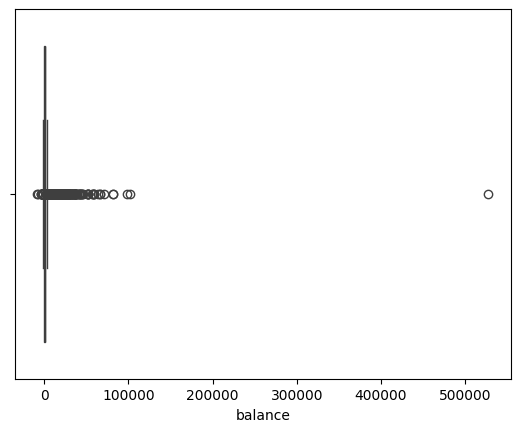

In [8]:
import seaborn as sns
sns.boxplot(x=data['balance'])


Preguntas – Observación

1. ¿Existen valores extremos? si en este caso 1

2. ¿Son positivos, negativos o ambos? positivo

3. ¿El boxplot te permite ver todos los detalles? No a detalle sino general

Preguntas – Estadística

4. ¿Cómo afectan los outliers a la media? En este caso este valor disparia la media a un valor mucho mas alto de lo verdadero

5. ¿La mediana se ve afectada? No tanto

6. ¿Qué estadístico sería más confiable aquí? podria ser la mediana

Preguntas – Decisión

7. ¿Eliminarías los outliers? Justifica.  Los convertiria en vez de eliminarlos y lo haria porque afectaria mucho las medidas de esa columna

8. ¿Podrían representar clientes reales? probablemente es un cliente real pero puede ser un dato mal digito

9. ¿Qué riesgos existen al eliminarlos sin análisis? que pueda ser un dato verdadero


Eje 1 – Datos vs Decisiones
• ¿Qué decisiones de limpieza son más riesgosas?
Rellenar datos faltantes sin un objetivo claro, ya que se puede malversar los demas datos

• ¿Qué errores podrían afectar un modelo futuro?
Eliminar información, ya que en un futuro se podria necesitar con otro fin

Eje 2 – Estadística vs Realidad
• ¿Los outliers siempre son errores?
No siempre puede llegar a ser solo un dato raro o anormal pero válido
• ¿La media es una buena medida para balance?
La media es extremadamente sensible a valores extremos entonces sola no tanto

Eje 3 – Preparación para el futuro
• ¿Qué información adicional pedirías antes de modelar?
Pediria el contexto del proyecto y tambien los factores que insiden

• ¿Qué variable analizarías más a fondo?
La respuesta o en este caso "y" es a la que mas cuidado daria